In [1]:
%pylab inline
%mkdir Plots

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
mkdir: Plots: File exists


In [2]:
import sys

In [3]:
from field_load_1d import *
# import dephasingless_pwpa_plasma_profile as depa

In [4]:
dump = 7
dt = osiris_get_run_info("dt")
ndumps = osiris_get_run_info("ndump")
dt_dump = dt*ndumps

z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles = 'photons')

k = np.linspace(0, 25, 100)
xi = np.linspace(-12, 0, 100)

stuff, xedges, yedges = np.histogram2d(z - dump*dt_dump, p1, bins = [xi, k], weights = wgt)
plt.pcolormesh(xi, k, np.transpose(stuff))


NameError: name 'osiris_get_run_info' is not defined

In [15]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy.constants as const
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import shutil
from scipy.signal import hilbert
from matplotlib.colors import LinearSegmentedColormap
from scipy.fft import fft, fftfreq, fftshift
from tftb.processing import WignerVilleDistribution
from tftb.processing import PseudoWignerVilleDistribution
from tftb.processing import Spectrogram
from matplotlib.colors import PowerNorm
from matplotlib import cm
import matplotlib
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
import glob
from scipy.integrate import solve_ivp

In [ ]:
def CustomCmap2(from_rgb,to_rgb):

    # from color r,g,b
    r1,g1,b1 = from_rgb

    # to color r,g,b
    r2,g2,b2 = to_rgb

    cdict = {'red': ((0, r1, r1),
                     (1, r2, r2)),
           'green': ((0, g1, g1),
                     (1, g2, g2)),
           'blue': ((0, b1, b1),
                    (1, b2, b2))}

    cmap = LinearSegmentedColormap('custom_cmap', cdict)
    return cmap

def CustomCmap3(from_rgb, mid_rgb, to_rgb):

    r1,g1,b1 = from_rgb

    r2,g2,b2 = mid_rgb
    
    r3,g3,b3 = to_rgb

    cdict = {'red': ((0, r1, r1),
                     (0.5, r2, r2),
                     (1, r3, r3)),
           'green': ((0, g1, g1),
                     (0.5, g2, g2),
                     (1, g3, g3)),
           'blue': ((0, b1, b1),
                    (0.5, b2, b2),
                    (1, b3, b3))}
             
    cmap = LinearSegmentedColormap('custom_cmap', cdict)
    return cmap

cmap_red = CustomCmap3([0.6, 0, 0], [1, 0, 0], [1, 0.6, 0])
cmap_green = CustomCmap3([0, 0.5, 0], [0, 1, 0], [0.7, 1, 0.7])
cmap_blue = CustomCmap2([0, 0, 1], [0, 1, 1])

In [ ]:
c_white_trans = matplotlib.colors.colorConverter.to_rgba('white', alpha = 0.)
cmap_jet = matplotlib.colors.LinearSegmentedColormap.from_list('cmap_jet', ['w', 'blue', 'cyan', 'lime','yellow', 'r', 'darkred' ], 256)
cmap_jet2 = matplotlib.colors.LinearSegmentedColormap.from_list('cmap_jet2', [c_white_trans, 'blue', 'cyan', 'lime','yellow', 'r', 'darkred' ], 128)

In [ ]:
def osiris_get_run_info(param, number = True, dim = 1, it = 1):
    file = open("run-info")
    lines = file.readlines()
    val = [None]*dim
    for line in lines:
        if ("  " + param) in line:
            it = it - 1
            for i in range(dim):
                val[i] = line.split()[2+i]
                val[i] = val[i][:-1]

        if (it == 0):
            break

    if (number):
        for i in range(dim):
            val[i] = float(val[i].replace("d0", ""))

    if (dim > 1):
        return val
    else:
        return val[0]

In [ ]:
def osiris_get_total_dumps():
    dt = osiris_get_run_info("dt")
    tmax = osiris_get_run_info("tmax")
    tmin = osiris_get_run_info("tmin")
    ndump = osiris_get_run_info("ndump")

    dt_dump = ndump*dt
    total_dumps = int(np.ceil((tmax-tmin)/dt_dump))
    return total_dumps

In [ ]:
def osiris_density_volume_factor():
    #n0 = osiris_get_run_info("n0")*(100)**3
    #return np.sqrt(n0)*((1.6e-19)/(3.0e8)/np.sqrt((9.11e-31)*(8.85e-12)))**3
    return 1

In [ ]:
def total_laser_energy():
    V = osiris_density_volume_factor()
    
    f = open("HIST/fld_ene")
    lines = f.readlines()
    lines = lines[2:]
    
    t = np.zeros(np.shape(lines))
    U = np.zeros(np.shape(lines))
    for k in range(np.size(lines)):
        lines[k] = lines[k].split()
        t[k] = float(lines[k][1])
        U[k] = float(lines[k][3]) + float(lines[k][4]) + float(lines[k][6]) + float(lines[k][7])
            
    U = U/V
    
    return t, U

def total_wakefield_energy(modes = [0, 1]):
    V = osiris_density_volume_factor()
    
    f = open("HIST/fld_ene")
    lines = f.readlines()
    lines = lines[2:]
    
    t = np.zeros(np.shape(lines))
    U = np.zeros(np.shape(lines))
    for k in range(np.size(lines)):
        lines[k] = lines[k].split()
        t[k] = float(lines[k][1])
        U[k] = float(lines[k][2]) + float(lines[k][5])
                        
    U = U/V
    
    return t, U

def total_particle_kinetic_energy(particle_number = 1):
    V = osiris_density_volume_factor()
    
    f = open("HIST/par%s_ene"%(str(particle_number).zfill(2)))
    lines = f.readlines()
    lines = lines[2:]
    
    t = np.zeros(np.shape(lines))
    K = np.zeros(np.shape(lines))
    N = np.zeros(np.shape(lines))
    for k in range(np.size(lines)):
        lines[k] = lines[k].split()
        t[k] = float(lines[k][1])
        N[k] = float(lines[k][2])
        K[k] = float(lines[k][3])            
        
    K = K/V
    
    return t, K, N

In [ ]:
def plot_total_energies(filename = "none", figsize = (12, 8)):
    
    t, U_L = total_laser_energy()
    _, U_w = total_wakefield_energy()
    _, U_p, _ = total_particle_kinetic_energy()
    _, U_b, _ = total_particle_kinetic_energy(particle_number = 2)

    fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = figsize)
    fig.tight_layout()
    

    ax[0, 0].plot(t, U_L, color = 'red')
    ax[0, 0].set_title('Laser', fontsize = 'xx-large')
    ax[0, 0].set_xlabel('time [$\omega_{p0}^{-1}$]', fontsize = 'xx-large')
    ax[0, 0].set_ylabel('Energy [$m_ec^2$]', fontsize = 'xx-large')
    ax[0, 0].grid()

    ax[0, 1].plot(t, U_b, color = 'green')
    ax[0, 1].set_title('Beam', fontsize = 'xx-large')
    ax[0, 1].set_xlabel('time [$\omega_{p0}^{-1}$]', fontsize = 'xx-large')
    ax[0, 1].set_ylabel('Energy [$m_ec^2$]', fontsize = 'xx-large')
    ax[0, 1].grid()

    ax[1, 0].plot(t, U_w, color = 'cyan')
    ax[1, 0].set_title('Wakefield', fontsize = 'xx-large')
    ax[1, 0].set_xlabel('time [$\omega_{p0}^{-1}$]', fontsize = 'xx-large')
    ax[1, 0].set_ylabel('Energy [$m_ec^2$]', fontsize = 'xx-large')
    ax[1, 0].grid()

    ax[1, 1].plot(t, U_p, color = 'blue')
    ax[1, 1].set_title('Plasma', fontsize = 'xx-large')
    ax[1, 1].set_xlabel('time [$\omega_{p0}^{-1}$]', fontsize = 'xx-large')
    ax[1, 1].set_ylabel('Energy [$m_ec^2$]', fontsize = 'xx-large')
    ax[1, 1].grid()
    
    fig.tight_layout()
    
    if (filename != "none"):
        fig.savefig("Plots/" + filename, bbox_inches = "tight", facecolor = "white")
        
    np.save('../B_analysis/U_L2.npy', U_L)
    
    return fig, ax


In [ ]:
def transformer_ratio(filename = "none", freqshift_levels = np.array([]), level_inds = np.array([]), figsize = (8, 6),  dump_rampend = 0):
    t, U_L = total_laser_energy()
    _, U_b, _ = total_particle_kinetic_energy(particle_number = 2)
    
    dt = t[1] - t[0]
    
    dU_Ldt = np.gradient(U_L, dt)
    dU_bdt = np.gradient(U_b, dt)
    
    R_inst = -dU_Ldt/dU_bdt
    R_cumu = np.zeros(np.shape(R_inst))
    R_cumu[1:] = -(U_L[1:] - U_L[0])/(U_b[1:] - U_b[0])
    
    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = figsize)
    fig.tight_layout()
    
    ax[0].plot(t[dump_rampend:], R_inst[dump_rampend:], color = "darkgreen")
    ax[0].set_title(r"Instantaneous Transformer Ratio", fontsize = 'xx-large')
    ax[0].set_xlabel(r"$t$ [$\omega_{p0}^{-1}$]", fontsize = 'xx-large')
    ax[0].set_ylabel(r"$\frac{-dU_L}{dU_b}$", fontsize = 'xx-large')
    for i in range(np.size(level_inds)):
        ax[0].axvline(t[level_inds[i]], linestyle = '--', color = 'black')
        if (np.size(freqshift_levels) > 0):
            ax[0].text(t[level_inds[i]] + dt, ax[0].get_ylim()[1] - np.ptp(ax[0].get_ylim())*0.05*i, '%.1fx shift' %(freqshift_levels[i]), ha='left', va='top', color='black', fontsize = 'large')
    ax[0].grid()
    
    ax[1].plot(t[dump_rampend:], R_cumu[dump_rampend:], color = "darkgreen")
    ax[1].set_title(r"Cumulative Transformer Ratio", fontsize = 'xx-large')
    ax[1].set_xlabel(r"$t$ [$\omega_{p0}^{-1}$]", fontsize = 'xx-large')
    ax[1].set_ylabel(r"$\frac{-(U_L - U_{L0})}{U_b - U_{b0}}$", fontsize = 'xx-large')
    for i in range(np.size(level_inds)):
        ax[1].axvline(t[level_inds[i]], linestyle = '--', color = 'black')
        if (np.size(freqshift_levels) > 0):
            ax[1].text(t[level_inds[i]] + dt, ax[1].get_ylim()[1] - np.ptp(ax[1].get_ylim())*0.05*i, '%.1fx shift' %(freqshift_levels[i]), ha='left', va='top', color='black', fontsize = 'large')
    ax[1].grid()
    
    fig.tight_layout()
    fig.subplots_adjust(wspace = 0.5)
    
    if (filename != "none"):
        fig.savefig("Plots/" + filename, bbox_inches = "tight", facecolor = "white")
    
    if (np.size(level_inds) == 0):
        return np.max(R_inst), np.max(R_cumu), fig, ax
    else:
        return R_inst[level_inds], R_cumu[level_inds], fig, ax

In [ ]:
def dispersion_trajectory(filename = "none", xilim = np.array([]), klim = np.array([]), freqshift_levels = np.array([]), dump_interval = 1, z_step = 1, figsize = (14, 6)):
    
    
    #if ((np.size(freqshift_levels) > 0) & (dump_interval > 1)):
    #    dump_interval = 1
    #    print("Setting dump_interval = 1 to calculate frequency shift levels")   
    
    total_dumps = osiris_get_total_dumps()
    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    dt_dump = dt*ndumps
    z0_laser = osiris_get_run_info("lon_x0")
    B = osiris_get_run_info("init_b0")
    pol = osiris_get_run_info("pol_type")
    k_delta0 = osiris_get_run_info('omega0')
    
    fig, ax = plt.subplots(1, 2, figsize = figsize, sharex = True)
    
    t = np.arange(0, dt_dump*total_dumps, dt_dump)
    xi_centroid = np.zeros(np.shape(t))
    k_centroid = np.zeros(np.shape(t))
    
    dz = osirisGridSpacing(0)*z_step
    z = osirisLoadGrid(0)[::z_step]
    xi = z - t[0]
    k = 2*np.pi*fftfreq(np.size(z), d = dz)
    k = k[:(np.size(z) // 2 + 1)]
    if (np.size(klim)==0):
        indkmax = -1
    else:
        indkmax = np.argmin(np.abs(k - klim[1]))
    
    spectrum = np.zeros((total_dumps, np.size(k[:indkmax+1])))
    envelope = np.zeros((total_dumps, np.size(z)))

    
    for dump in range(0, total_dumps, dump_interval):
        E_x = osirisLoadEField(dump, component = 2)[::z_step]
        
        E_xh = hilbert(E_x)
        envelope[dump, :] = np.abs(E_xh)
        k_x = np.gradient(np.unwrap(np.angle(E_xh)), dz)
        
        '''
        xi_centroid[dump] = np.sum(xi*np.abs(E_xh)**2)/np.sum(np.abs(E_xh)**2)
        ind_centroid = argmin(np.abs(xi - xi_centroid[dump]))
        k_centroid[dump] = k_x[ind_centroid]
        '''
        
        xi_centroid[dump] = xi[np.argmax(np.abs(E_xh))]
        
        E_k = fft(E_x)
        k_centroid[dump] = k[np.argmax(np.abs(E_k))]
        spectrum[dump, :indkmax+1] = np.abs(E_k[:indkmax+1])
        
        print("Dump %d of %d calculated"%(dump+1, total_dumps))
    
    t = t[::dump_interval]
    k_centroid = k_centroid[::dump_interval]
    xi_centroid = xi_centroid[::dump_interval]
    spectrum = spectrum[::dump_interval]
    envelope = envelope[::dump_interval]
    
    
    pc0 = ax[0].pcolormesh(t, xi, np.transpose(envelope)/np.max(envelope), cmap = 'plasma', shading = 'gouraud')
    ax[0].plot(t, xi_centroid, color = 'white', linewidth = 2.5, label = 'simulation centroid')
    ax[0].set_ylabel(r"$k_{p0}\xi$", fontsize = 22)
    ax[0].set_xlabel(r"$\omega_{p0}t$", fontsize = 22)
    ax[0].tick_params(labelsize = 18)
    if (np.size(xilim) > 0):
        ax[0].set_ylim(xilim[0], xilim[1])
    cbar1 = fig.colorbar(pc0, ax = ax[0])
    cbar1.set_label(label = 'envelope [arb units]', fontsize = 22)
    cbar1.ax.tick_params(labelsize = 18)
    cbar1.set_ticks([0, 0.4, 0.7, 1])
    
    pc1 = ax[1].pcolormesh(t, k[:indkmax+1]/k_delta0, np.transpose(spectrum)/np.max(spectrum), cmap = 'turbo', shading = 'gouraud')
    ax[1].plot(t, k_centroid/k_delta0, color = 'white', linewidth = 2.5, label = 'simulation centroid')
    ax[1].set_ylabel(r"$k/k_0$", fontsize = 22)
    ax[1].set_xlabel(r"$\omega_{p0}t$", fontsize = 22)
    #ax[1].set_title('Centroid Wave Number', fontsize = 20)
    ax[1].tick_params(labelsize = 18)
    if (np.size(klim) > 0):
        ax[1].set_ylim(klim[0]/k_delta0, klim[1]/k_delta0)
    cbar2 = fig.colorbar(pc1, ax = ax[1])
    cbar2.set_label(label = 'spectrum [arb units]', fontsize = 22)
    cbar2.ax.tick_params(labelsize = 19)
    cbar2.set_ticks([0, 0.4, 0.7, 1])
        
    fig.tight_layout()
    
    if (filename != "none"):
        fig.savefig("Plots/" + filename, bbox_inches = "tight", facecolor = "white")
                
    return fig, ax, xi_centroid, k_centroid

In [ ]:
def dispersion_trajectory_combined(n_driver, L_driver, z0_beamfront, z_startPWPA, filename = "none", xilim = np.array([]), klim = np.array([]), freqshift_levels = np.array([]), dump_interval = 1, figsize = (8, 10)):
    
    
    #if ((np.size(freqshift_levels) > 0) & (dump_interval > 1)):
    #    dump_interval = 1
    #    print("Setting dump_interval = 1 to calculate frequency shift levels")   
    
    total_dumps = osiris_get_total_dumps()
    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    dt_dump = dt*ndumps
    z0_laser = osiris_get_run_info("lon_x0")
    
    fig, ax = plt.subplots(2, 1, figsize = figsize, sharex = True)
    
    t = np.arange(0, dt_dump*total_dumps, dt_dump)
    xi_centroid = np.zeros(np.shape(t))
    k_centroid = np.zeros(np.shape(t))
    xi_delta_aligned = np.zeros(np.shape(t))
    k_delta_aligned = np.zeros(np.shape(t))
    
    dz = osirisGridSpacing(0)
    z = osirisLoadGrid(0)
    xi = z - t[0]
    k = 2*np.pi*fftfreq(np.size(z), d = dz)
    k = k[:(np.size(z) // 2 + 1)]
    
    spectrum = np.zeros((total_dumps, np.size(z) // 2 + 1))
    envelope = np.zeros((total_dumps, np.size(z)))

    z_depa, n_depa, k_delta_sqr = depa.get_pwpa_profile(osiris_get_run_info("omega0")**2, n_driver, L_driver, kp0z_final = osiris_get_run_info("tmax"), n_steps = total_dumps)
    k_delta = np.sqrt(k_delta_sqr)
    zeta_delta = depa.get_tau_where_delta_n_is_0(n_driver, L_driver, n_depa)
    
    for dump in range(0, total_dumps, dump_interval):
        E_x = osirisLoadEField(dump, component = 2)
        
        E_xh = hilbert(E_x)
        envelope[dump, :] = np.abs(E_xh)
        k_x = np.gradient(np.unwrap(np.angle(E_xh)), dz)
        
        xi_centroid[dump] = np.sum(xi*np.abs(E_xh)**2)/np.sum(np.abs(E_xh)**2)
        ind_centroid = argmin(np.abs(xi - xi_centroid[dump]))
        k_centroid[dump] = k_x[ind_centroid]
        
        E_k = fft(E_x)
        spectrum[dump, :] = np.abs(E_k[:(np.size(z) // 2 + 1)])

        ind_depa = np.argmin(np.abs(z_depa + z_startPWPA - (z0_laser + dump*dt_dump)))
        xi_delta_aligned[dump] = z0_beamfront - zeta_delta[ind_depa]
        k_delta_aligned[dump] = k_delta[ind_depa]
        
        print("Dump %d of %d calculated"%(dump+1, total_dumps))
    
    t = t[::dump_interval]
    k_centroid = k_centroid[::dump_interval]
    xi_centroid = xi_centroid[::dump_interval]
    spectrum = spectrum[::dump_interval]
    envelope = envelope[::dump_interval]
    
    level_inds = np.zeros(np.shape(freqshift_levels), dtype = 'int')
    for i in range(np.size(freqshift_levels)):
        level_inds[i] = int(dump_interval*np.argmin(np.abs(k_centroid/k_centroid[0] - freqshift_levels[i])))
    
    pc0 = ax[0].pcolormesh(t, xi, np.transpose(envelope), cmap = 'plasma', shading = 'gouraud')
    ax[0].plot(t, xi_centroid, color = 'white', linewidth = 2.5, label = 'simulation centroid')
    ax[0].plot(t, xi_delta_aligned, color = 'gray', linewidth = 2.5, linestyle = 'dashed', label = 'theory centroid')
    ax[0].set_ylabel(r"$\xi_z$ [$c/\omega_p$]", fontsize = "xx-large")
    ax[0].set_title('Centroid Position and Wave Number of Laser Pulse', fontsize = "xx-large")
    ax[0].legend(fontsize = 24, loc = 'upper right')
    ax[0].tick_params(labelsize = 24)
    if (np.size(xilim) > 0):
        ax[0].set_ylim(xilim[0], xilim[1])
    fig.colorbar(pc0, ax = ax[0], label = 'envelope (arb. units)')
    
    pc1 = ax[1].pcolormesh(t, k, np.transpose(spectrum), cmap = 'turbo', shading = 'gouraud')
    ax[1].plot(t, k_centroid, color = 'white', linewidth = 2.5, label = 'simulation centroid')
    ax[1].plot(t, k_delta_aligned, color = 'gray', linewidth = 2.5, linestyle = 'dashed', label = 'theory centroid')
    ax[1].set_ylabel(r"$k_z$ [$\omega_{p0}/c$]", fontsize = 24)
    ax[1].set_xlabel(r"$t$ [$\omega_{p0}/c$]", fontsize = 24)
    ax[1].legend(fontsize = 24, loc = 'upper right')
    ax[1].tick_params(labelsize = 24)
    if (np.size(klim) > 0):
        ax[1].set_ylim(klim[0], klim[1])
    fig.colorbar(pc1, ax = ax[1], label = 'spectrum (arb. units)')
    
    for i in range(np.size(level_inds)):
        ax[0].axvline(t[int(level_inds[i]/dump_interval)], linestyle = '--', color = 'gold')
        ax[0].text(t[int(level_inds[i]/dump_interval)] + dt, ax[0].get_ylim()[1] - np.ptp(ax[0].get_ylim())*0.05*i, '%.1fx shift' %(freqshift_levels[i]), ha='left', va='top', color='gold', fontsize = 'large')
    
    for i in range(np.size(level_inds)):
        ax[1].axvline(t[int(level_inds[i]/dump_interval)], linestyle = '--', color = 'gold')
        
    fig.tight_layout()
    plt.subplots_adjust(hspace=0)
    
    if (filename != "none"):
        fig.savefig("Plots/" + filename, bbox_inches = "tight", facecolor = "white")
        
    return level_inds, fig, ax

In [5]:
def animate_wakefield_sliver(dir, beam_name = "driver", dump_interval = 1, figsize = (12, 8), dump_rampend = 0):
    
    dir = "Plots/"+dir
    
    if os.path.exists(dir):
        shutil.rmtree(dir)
    os.makedirs(dir)
    
    total_dumps = osiris_get_total_dumps()
    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    dt_dump = dt*ndumps
    
    fig, ax1 = plt.subplots(figsize = figsize)
    ax2 = ax1.twinx()
    
    E_x = [None]*total_dumps
    n_p = [None]*total_dumps
    n_b = [None]*total_dumps
    
    for dump in range(0, total_dumps, dump_interval):
        E_x[dump] = osirisLoadEField(dump, component = 2)
        n_p[dump] = np.abs(osirisLoadDensity(dump, species = 'plasma'))
        n_b[dump] = np.abs(osirisLoadDensity(dump, species = beam_name))
        print("Frame %d of %d loaded"%(dump+1, total_dumps))
        
    ymin1 = np.min(E_x[dump_rampend::dump_interval])
    ymax1 = np.max(E_x[dump_rampend::dump_interval])
    ymin2 = np.min([n_p[dump_rampend::dump_interval], n_b[dump_rampend::dump_interval]])
    ymax2 = np.max([n_p[dump_rampend::dump_interval], n_b[dump_rampend::dump_interval]])
    for dump in range(0, total_dumps, dump_interval):
    
        z = osirisLoadGrid(dump)
    
        ax1.cla()
        ax2.cla()
        
        ax1.plot(z, E_x[dump], color = 'red', label = "$E_x$")
        ax2.plot(z, n_p[dump], color = 'blue', label = "$n_p$", linestyle = ":")
        ax2.plot(z, n_b[dump], color = 'green', label = "$n_b$", linestyle = "-.")
        
        ax1.set_title("Laser Wakefield Slice | $\omega_{p0} t$ = %.2f"%(dump*dt_dump), fontsize = 24)
        ax1.set_xlabel("$z$ [$c/\omega_{p0}$]", fontsize = 24)
        ax1.set_ylabel("electric field [$m_ec\omega_{p0}/e$]", fontsize = 24)
        ax2.set_ylabel("density [$n_{0}$]", fontsize = 24)
        ax2.yaxis.set_label_position("right")
        ax1.set_ylim(ymin1, ymax1)
        ax2.set_ylim(ymin2, ymax2)
        ax1.legend()
        ax2.legend()
        print("Frame %d of %d plotted"%(dump+1, total_dumps))
        
        fig.tight_layout()
        fig.savefig(dir + "/frame%d.png" %(dump), bbox_inches = "tight", facecolor = "white")
        

<>:42: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\o'
<>:42: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\o'
/var/folders/8r/54ff920x5wncwyryjmbth6mh0000gn/T/ipykernel_10107/4220356835.py:42: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_title("Laser Wakefield Slice | $\omega_{p0} t$ = %.2f"%(dump*dt_dump), fontsize = 24)
/var/folders/8r/54ff920x5wncwyryjmbth6mh0000gn/T/ipykernel_10107/4220356835.py:43: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel("$z$ [$c/\omega_{p0}$]", fontsize = 24)
/var/folders/8r/54ff920x5wncwyryjmbth6mh0000gn/T/ipykernel_10107/4220356835.py:44: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_ylabel("electric field [$m_ec\omega_{p0}/e$]", fontsize = 24)


In [6]:
def animate_p1x1_phasespace(dir, species = 'plasma', species_number = 1, gamma = 0.25, figsize = (12, 8), dump_interval = 1, ymin = float("NaN"), ymax = float("NaN")):

    dir = "Plots/"+dir

    if os.path.exists(dir):
        shutil.rmtree(dir)
    os.makedirs(dir)

    total_dumps = osiris_get_total_dumps()
    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    dt_dump = dt*ndumps
    m = np.abs(osiris_get_run_info("rqm", it = species_number))
    #V = osiris_density_volume_factor()
    V = 1

    fig, ax = plt.subplots(figsize = figsize)

    f = [None]*total_dumps
    p_z = [None]*total_dumps
    z = [None]*total_dumps

    for dump in range(0, total_dumps, dump_interval):
        axes, f[dump] = osirisLoadPhaseSpace(dump, species = species)
        z[dump] = axes[0]
        p_z[dump] = axes[1]*m
        
        f[dump] = np.abs(f[dump]/m/V)
        print("Frame %d of %d loaded"%(dump+1, total_dumps))

    for dump in range(0, total_dumps, dump_interval):
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(3)
            
        im = ax.pcolormesh(z[dump], p_z[dump], f[dump], cmap = 'plasma', shading = 'auto', norm = matplotlib.colors.PowerNorm(gamma))
        ax.set_xlabel(r'$k_{p0}z$', fontsize = 'xx-large')
        ax.set_ylabel(r'$\frac{1}{m_ec}p_z$', fontsize = 'xx-large')
        ax.set_title(r'%s $p_zz$ Phase Space | $\omega_{p0}t$ = %f'%(species, dt_dump*dump), fontsize = 'xx-large')
        
        cbar = fig.colorbar(im)
        cbar.set_label(r"$\frac{m_ec^2}{\omega_{p0}} f(z, p_z)$", fontsize = 'xx-large')
        if not isnan(ymin):
            ax.set_ylim(ymin = ymin)
        if not isnan(ymax):
            ax.set_ylim(ymax = ymax)
        
        fig.tight_layout()
        fig.savefig(dir + "/frame%d.png" %(dump), bbox_inches = "tight", facecolor = "white")
        ax.cla()
        cbar.remove()
        print("Frame %d of %d plotted"%(dump+1, total_dumps))


In [7]:
def animate_laser_wigner(dir, xi_min=float('NaN'), z_step=1, cbarpad=0.1, n_sigma_interference=3,
                         figsize=(16, 10), smooth_window_per_dxi=0.01, nlim=np.array([]),
                         klim=np.array([]), wig_cutoff=0.01, dump_interval=1):
    dir = "Plots/" + dir

    if os.path.exists(dir):
        shutil.rmtree(dir)
    os.makedirs(dir)

    def next_even(n):
        return n if n % 2 == 0 else n + 1

    total_dumps = osiris_get_total_dumps()
    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    dt_dump = dt * ndumps

    # Load fixed window-frame grid once
    xi = osirisLoadGrid(0)[::z_step]
    dxi = osirisGridSpacing(0) * z_step
    if isnan(xi_min):
        xi_min = xi[0]
    xi_inds = (xi >= xi_min)
    xi = xi[xi_inds]

    for dump in range(0, total_dumps, dump_interval):
        fig, ax1 = plt.subplots(figsize=figsize)
        ax2 = ax1.twinx()

        # Load PKT electron density on fixed window-frame grid
        n_p_pkt_full = np.abs(osirisLoadDensity(dump, species='plasma', path=''))
        xi_pkt = np.linspace(xi[0], xi[-1], len(n_p_pkt_full))
        xi_inds_pkt = xi_pkt >= xi_min
        xi_pkt = xi_pkt[xi_inds_pkt]
        n_p_pkt = n_p_pkt_full[xi_inds_pkt]
        dxi_pkt = xi_pkt[1] - xi_pkt[0]
        gradn_p_pkt = savgol_filter(
            np.gradient(savgol_filter(n_p_pkt,
                        window_length=next_even(int(smooth_window_per_dxi * np.size(xi_pkt))) + 1,
                        polyorder=3), dxi_pkt),
            window_length=next_even(int(smooth_window_per_dxi * np.size(xi_pkt))) + 1,
            polyorder=3)

        # Load photon particles and convert to window frame
        z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles='photons')
        z_window = z - dump * dt_dump

        print('Frame %d of %d calculated' % (dump + 1, total_dumps))

        # Scatter plot of photon distribution in window frame
        ax2.scatter(z_window, p1, c=np.log10(wgt + 1e-10),
                    s=0.5, cmap='turbo', alpha=0.3, rasterized=True)

        if np.size(klim) > 0:
            ax2.set_ylim(klim[0], klim[1])
        ax2.set_xlim(xi[0], xi[-1])
        ax2.set_xlabel(r'$k_{p0}\xi$', fontsize=24)
        ax2.set_ylabel(r'$k/k_{p0}$', fontsize=24)
        ax2.tick_params(axis='both', labelsize=24)
        ax2.set_title('PKT Photon Distribution | $\omega_{p0}t$ = %f' % (dt_dump * dump), fontsize=24)

        ax1.plot(xi_pkt, gradn_p_pkt, color='blue',
                 label=r'$\frac{1}{k_{p0} n_0} \frac{\partial n_e}{\partial \xi}$', linewidth=2)
        ax1.plot(xi_pkt, n_p_pkt, color='green', linestyle='dashed',
                 label=r'$\frac{n_e}{n_0}$', linewidth=2)
        if np.size(nlim) > 0:
            ax1.set_ylim(nlim[0], nlim[1])
        ax1.set_xlim(xi[0], xi[-1])
        ax1.set_ylabel('electron density or smoothed density gradient', fontsize=24)
        ax1.grid()
        ax1.legend(fontsize=24)
        ax1.set_xlabel(r'$k_{p0}\xi$', fontsize=24)
        ax1.tick_params(axis='both', labelsize=24)

        fig.tight_layout()
        fig.savefig(dir + "/frame%d.png" % dump, bbox_inches="tight", facecolor="white")
        print('Frame %d of %d plotted' % (dump + 1, total_dumps))
        ax1.cla()
        ax2.cla()
        fig.clf()

<>:60: SyntaxWarning: invalid escape sequence '\o'
<>:60: SyntaxWarning: invalid escape sequence '\o'
/var/folders/8r/54ff920x5wncwyryjmbth6mh0000gn/T/ipykernel_10107/3250138344.py:60: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_title('PKT Photon Distribution | $\omega_{p0}t$ = %f' % (dt_dump * dump), fontsize=24)


In [8]:
h, xedges, yedges = animate_laser_wigner('wigner', z_step = 10, dump_interval = 1, klim = np.array([0, 20]), nlim = np.array([-4, 4]), figsize = (16, 10))

/var/folders/8r/54ff920x5wncwyryjmbth6mh0000gn/T/ipykernel_10107/3250138344.py:60: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_title('PKT Photon Distribution | $\omega_{p0}t$ = %f' % (dt_dump * dump), fontsize=24)


NameError: name 'os' is not defined

44 grad files found
44 dens files found
grad shape: (1504, 2)
dens shape: (1504, 2)
grad range: -28.17411853 38.56127456
dens range: 0.0 3.521928577


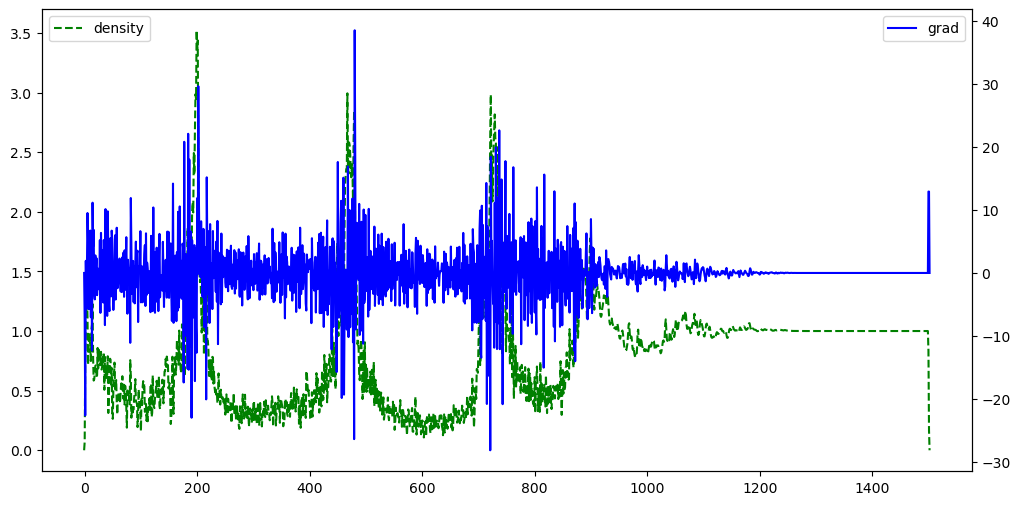

In [9]:
import glob

# NO FILTERING AT ALL
# grad_files = sorted(glob.glob('diag_unfilt_grad/grad_grid_*.txt'))
# dens_files = sorted(glob.glob('diag_unfilt_grad/density_*.txt'))

# After filtering GRADIENT of electron density once
# grad_files = sorted(glob.glob('diag_filt_grad1/grad_grid_*.txt'))
# dens_files = sorted(glob.glob('diag_filt_grad1/density_*.txt'))

# After filtering ELECTRON DENSITY once
# grad_files = sorted(glob.glob('diag_filt_den1/grad_grid_*.txt'))
# dens_files = sorted(glob.glob('diag_filt_den1/density_*.txt'))

# After filtering PHOTON DENSITY once
grad_files = sorted(glob.glob('diag_filt_phot_den1/grad_grid_*.txt'))
dens_files = sorted(glob.glob('diag_filt_phot_den1/density_*.txt'))

print(len(grad_files), 'grad files found')
print(len(dens_files), 'dens files found')

# just plot the first one
grad = np.loadtxt(grad_files[40])
dens = np.loadtxt(dens_files[40])

print('grad shape:', grad.shape)
print('dens shape:', dens.shape)
print('grad range:', grad[:,1].min(), grad[:,1].max())
print('dens range:', dens[:,1].min(), dens[:,1].max())

fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()
ax1.plot(dens[:,0], dens[:,1], 'g--', label='density')
ax2.plot(grad[:,0], grad[:,1], 'b-', label='grad')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

In [10]:
def animate_trines_phasespace(dir, figsize=(14, 8), klim=np.array([]), xlim=np.array([]),
                                nlim=np.array([]), dump_interval=1, ufl=7.0,
                                n_xi_bins=300, n_k_bins=150, grad_dir=None, dx=None):
    dir = "Plots/" + dir
    if os.path.exists(dir):
        shutil.rmtree(dir)
    os.makedirs(dir)
    total_dumps = osiris_get_total_dumps()
    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    dt_dump = dt * ndumps
    # Load fixed window-frame grid once
    xi = osirisLoadGrid(0)
    if np.size(xlim) > 0:
        xi_plot_min, xi_plot_max = xlim[0], xlim[1]
    else:
        xi_plot_min, xi_plot_max = xi[0], xi[-1]

    grad_files = sorted(glob.glob(grad_dir + '/grad_grid_*.txt')) if grad_dir else None
    if dx is None and xi.size > 1:
        dx = xi[1] - xi[0]

    # Load initial photon distribution once (green, t=0)
    z0, p1_0, p2_0, p3_0, ene_0, wgt_0 = osiris_particles(0, particles='photons')
    z0_window = z0 - 0 * dt_dump
    k0_norm = p1_0 / ufl
    for dump in range(0, total_dumps, dump_interval):
        fig, ax1 = plt.subplots(figsize=figsize)
        ax2 = ax1.twinx()
        # Load electron density on fixed window-frame grid
        n_e_full = np.abs(osirisLoadDensity(dump, species='plasma'))
        xi_e = np.linspace(xi[0], xi[-1], len(n_e_full))
        # Load current photon distribution
        z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles='photons')
        z_window = z - dump * dt_dump
        k_norm = p1 / ufl
        print('Frame %d of %d calculated' % (dump + 1, total_dumps))
        # Plot electron density (wake) on left axis
        ax1.plot(xi_e, n_e_full, color='black', linewidth=1.5,
                 label=r'$n_e / n_0$')
        ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')

        # --- gradient overlay, plotted on ax1, no new axis ---
        if grad_files is not None and dump < len(grad_files):
            grad = np.loadtxt(grad_files[dump])
            xi_grad = xi[0] + grad[:, 0] * dx
            ax1.plot(xi_grad, grad[:, 1], color='purple', linewidth=1.2,
                     alpha=0.8, label=r'$\nabla n_i$')

        ax1.set_ylabel(r'$n_e/n_0$', fontsize=22)
        ax1.set_ylim(0.0, 3.5)
        ax1.set_xlim(xi_plot_min, xi_plot_max)
        ax1.set_xlabel(r'$k_{p0}\xi$', fontsize=22)
        ax1.tick_params(axis='both', labelsize=18)
        ax1.legend(fontsize=16, loc='upper left')
        ax1.grid(alpha=0.3)
        # Build 2D histogram bins
        xi_bins = np.linspace(xi_plot_min, xi_plot_max, n_xi_bins)
        if np.size(klim) > 0:
            k_bins = np.linspace(klim[0], klim[1], n_k_bins)
        else:
            k_bins = np.linspace(min(k_norm.min(), k0_norm.min()),
                                  max(k_norm.max(), k0_norm.max()), n_k_bins)
        z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles='photons')
        z_window = z - dump * dt_dump

        wgt_threshold = wgt.max() * 0.05
        mask = wgt > wgt_threshold
        # Initial (green) distribution
        # ax2.scatter(z0_window, k0_norm, s=2*wgt_0/wgt_0.max(),
        #             color='green', alpha=0.3, rasterized=True, label='$t=0$')
        #Current (red) distribution
        ax2.scatter(z_window, k_norm, s=2*wgt/wgt.max(),
            color='blue', alpha=0.3, rasterized=True,
            label=r'$\omega_{p0}t = %.1f$' % (dt_dump * dump))

        if np.size(klim) > 0:
            ax2.set_ylim(klim[0], klim[1])
        ax2.set_xlim(xi_plot_min, xi_plot_max)
        ax2.set_ylabel(r'$k/\omega_0$', fontsize=22)
        ax2.tick_params(axis='both', labelsize=18)
        ax2.set_title(r'Photon Phase Space | $\omega_{p0}t$ = %.1f' % (dt_dump * dump),
                      fontsize=22)
        # Legend for photon colors
        green_patch = plt.Line2D([0], [0], marker='s', color='w',
                                  markerfacecolor='green', markersize=12, label='$t=0$')
        red_patch = plt.Line2D([0], [0], marker='s', color='w',
                                markerfacecolor='red', markersize=12,
                                label=r'$\omega_{p0}t = %.1f$' % (dt_dump * dump))
        ax2.legend(handles=[green_patch, red_patch], fontsize=16, loc='upper right')
        fig.tight_layout()
        fig.savefig(dir + "/frame%d.png" % dump, bbox_inches="tight", facecolor="white")
        print('Frame %d of %d plotted' % (dump + 1, total_dumps))
        ax1.cla()
        ax2.cla()
        fig.clf()

In [11]:
animate_trines_phasespace('trines_match', klim=np.array([0.0, 1.8]), 
                           xlim=np.array([50, 108]), ufl=7.0, grad_dir='diag')

NameError: name 'os' is not defined

Frame 1 of 7954 calculated
Frame 1 of 7954 plotted
Frame 2 of 7954 calculated
Frame 2 of 7954 plotted
Frame 3 of 7954 calculated
Frame 3 of 7954 plotted
Frame 4 of 7954 calculated
Frame 4 of 7954 plotted
Frame 5 of 7954 calculated
Frame 5 of 7954 plotted
Frame 6 of 7954 calculated
Frame 6 of 7954 plotted
Frame 7 of 7954 calculated
Frame 7 of 7954 plotted
Frame 8 of 7954 calculated
Frame 8 of 7954 plotted
Frame 9 of 7954 calculated
Frame 9 of 7954 plotted
Frame 10 of 7954 calculated
Frame 10 of 7954 plotted
Frame 11 of 7954 calculated
Frame 11 of 7954 plotted
Frame 12 of 7954 calculated
Frame 12 of 7954 plotted
Frame 13 of 7954 calculated
Frame 13 of 7954 plotted
Frame 14 of 7954 calculated
Frame 14 of 7954 plotted
Frame 15 of 7954 calculated
Frame 15 of 7954 plotted
Frame 16 of 7954 calculated
Frame 16 of 7954 plotted
Frame 17 of 7954 calculated
Frame 17 of 7954 plotted
Frame 18 of 7954 calculated
Frame 18 of 7954 plotted
Frame 19 of 7954 calculated
Frame 19 of 7954 plotted
Frame 20 of

/var/folders/8r/54ff920x5wncwyryjmbth6mh0000gn/T/ipykernel_44039/2434529080.py:28: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax1 = plt.subplots(figsize=figsize)


Frame 21 of 7954 plotted
Frame 22 of 7954 calculated
Frame 22 of 7954 plotted
Frame 23 of 7954 calculated
Frame 23 of 7954 plotted
Frame 24 of 7954 calculated
Frame 24 of 7954 plotted
Frame 25 of 7954 calculated
Frame 25 of 7954 plotted
Frame 26 of 7954 calculated
Frame 26 of 7954 plotted
Frame 27 of 7954 calculated
Frame 27 of 7954 plotted
Frame 28 of 7954 calculated
Frame 28 of 7954 plotted
Frame 29 of 7954 calculated
Frame 29 of 7954 plotted
Frame 30 of 7954 calculated
Frame 30 of 7954 plotted
Frame 31 of 7954 calculated
Frame 31 of 7954 plotted
Frame 32 of 7954 calculated
Frame 32 of 7954 plotted
Frame 33 of 7954 calculated
Frame 33 of 7954 plotted
Frame 34 of 7954 calculated


KeyboardInterrupt: 

<Figure size 1400x800 with 0 Axes>

...

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

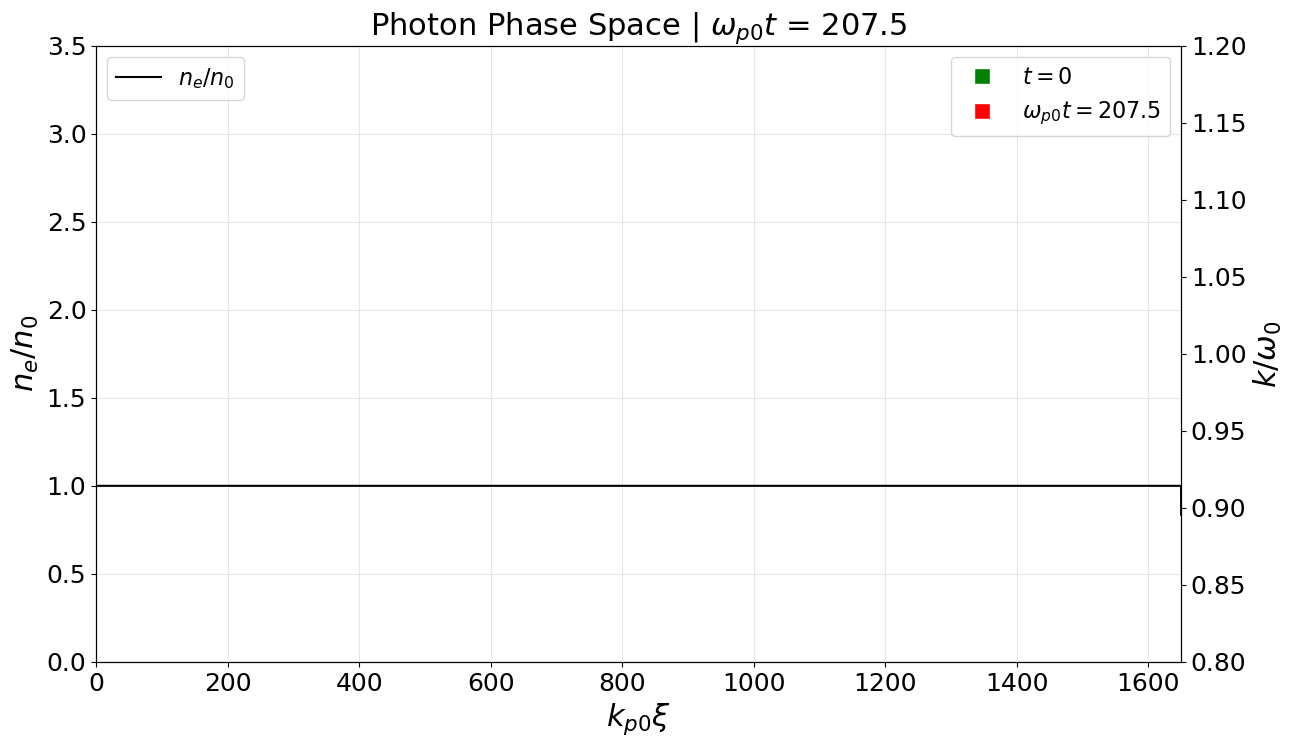

In [94]:
animate_trines_phasespace('reitsma_match', klim=np.array([0.8, 1.2]), 
                           xlim=np.array([0, 1650.0]), ufl=20.0)

# 05: Analytic Comparison -- Linear

The below cell is for some nice functions.

In [89]:
def extract_data(dump, v_g):
    # Get the total number of dumps and the timestep
    ndumps = osiris_get_run_info("ndump")
    dt = osiris_get_run_info("dt")

    # Calculate the ..
    t = dump * dt * ndumps

    # Grab the longitudinal E-field, electron density and load the initial grid
    E_z = osirisLoadEField(dump, component=1)
    n_e = np.abs(osirisLoadDensity(dump, species='plasma'))
    xi = osirisLoadGrid(0)
    zeta = xi - v_g * t

    xi_pho = osirisLoadGrid(0)
    n_pho = osirisLoadDensity(dump, species='photons')
    zeta_pho = xi_pho - v_g * t

    return zeta, E_z, n_e, t, zeta_pho, n_pho

def smooth_1d(arr, passes=15):
    a = arr.copy()
    for _ in range(passes):
        tmp = 0.25*np.roll(a,1) + 0.5*a + 0.25*np.roll(a,-1)
        tmp[0], tmp[-1] = a[0], a[-1]
        a = tmp
    return a

# Returns the analytic solution (for the sine-squared pulse case) found in Esarey2009
def linear_wake_sine(zeta, a0, k_p, zeta_pulse_end):
    # Create arrays for the analytic axial E-field and density perturbations
    Ez_E0 = np.zeros_like(zeta)
    dn_n0 = np.zeros_like(zeta)

    # Restrict the analytic solution so nothing shows up in or in front of the beam
    behind = zeta < zeta_pulse_end

    # Behind the beam, this is the solution 
    Ez_E0[behind] = -(np.pi/4) * (a0**2) * np.cos(k_p * (zeta[behind] - zeta_pulse_end))
    dn_n0[behind] = -(np.pi/4) * (a0**2) * np.sin(k_p * (zeta[behind] - zeta_pulse_end))
    
    return Ez_E0, dn_n0

Now compare everything to the actual data.

In [70]:
# Which dump do you want to look at?
dump = 100

# What is the group velocity of the beam?
v_g = np.sqrt(99.0/100.0)

# Get all of the relevant OSIRIS data for this dump
zeta, Ez, n_e, t = extract_data(dump, v_g=v_g)

# Smooth the electron density data because I was having issues with noise
n_e_smoothed = smooth_1d(n_e)

# Figure out where the wake starts (where it's above some threshold). We'll say that this is where the 
# beam/pulse/whatever "ends" so we can give that to our analytic solution. The threshold is a bit touchy.
active = np.abs(Ez) > 1e-3
zeta_pulse_end = zeta[active].max()

# Calculate the analytic solution given everything we know from the input deck
Ez_analytic, dn_analytic = linear_wake_sine(zeta, a0=0.25, k_p=1.0, zeta_pulse_end=zeta_pulse_end)

# Create a figure for the comparison
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,8))

# On the top plot, put the axial electric field calculations
ax1.plot(zeta, Ez, label='OSIRIS')
ax1.plot(zeta, Ez_analytic, '--', label='Linear theory')
ax1.legend(); ax1.set_ylabel(r'$E_z/E_0$', fontsize=13)
ax1.set_title(f'Dump {dump}, t={t:.2f}')

# On the bottom plot, put the electron density perturbation calculations
ax2.plot(zeta, n_e_smoothed - 1.0, label='OSIRIS (smoothed)')
ax2.plot(zeta, dn_analytic, '--', label='Linear theory')
ax2.legend(); ax2.set_ylabel(r'$\delta n/n_0$', fontsize=13); ax2.set_xlabel(r'$k_{p0}\zeta$', fontsize=13);

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './MS/FLD/e1/e1-000100.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

# 06: Analytic Comparison -- Nonlinear

We already have our nice functions defined above, so the following is a function which uses solve_ivp to solve equation 20 from the Esarey2009 paper (which is already in the nonlinear limit):
$$
k_p^{-2} \frac{\partial^2\phi}{\partial\xi^2} = \frac{\left(1+a^2\right)}{2\left(1+\phi\right)^2} - \frac{1}{2}.
$$

In [447]:
def fit_pulse_envelope(dump, v_g, species='photons', window_width=15.0):
    def gaussian_envelope(x, a0, x0, L_rms):
        return a0 * np.exp(-(x - x0)**2 / (2 * L_rms**2))

    dt = osiris_get_run_info("dt")
    ndumps = osiris_get_run_info("ndump")
    t = dump * dt * ndumps

    xi = osirisLoadGrid(dump, species=species) - v_g * t
    q = osirisLoadDensity(dump, species=species)
    z_peak_guess = xi[np.argmax(q)]

    p0 = [q.max(), z_peak_guess, 2.0]
    bounds = ([0, xi.min(), 0.01], [10, xi.max(), 30])

    popt, _ = curve_fit(gaussian_envelope, xi, q, p0=p0, bounds=bounds)
    a0_sq_fit, x0_fit, L_rms_fit = popt

    return np.sqrt(a0_sq_fit), L_rms_fit, x0_fit

def solve_nonlinear_wake(a0, L_rms, k_p, k_carrier, zeta_range, n_points=10000):

    # Define a function which calculates the pulse profile based on the user's inputs
    def a2(z):
        return a0**2 * np.exp(-z**2 / (2*L_rms**2))

    # Define a function which defines the RHS of the above differential equation (this is for solve_ivp).
    # We need to split the above second-order differential equation into two first-order differential equations.
    def rhs(z, y):
        phi, dphi = y
        d2phi = k_p**2 * ((1+a2(z)) / (2*(1+phi)**2) - 0.5)
        return [dphi, d2phi]

    # Define the initial conditions and range across which we'd like to evaluate
    y0 = [0.0, 0.0]
    zeta_eval = np.linspace(zeta_range[0], zeta_range[1], n_points)

    # Finally, solve the initial value problem given everything we've calculated and everything we've been given
    sol = solve_ivp(rhs, [zeta_range[0], zeta_range[1]], y0,
                    t_eval=zeta_eval, method='RK45', 
                    rtol=1e-8, atol=1e-10)

    # Define the solution for output
    zeta = sol.t
    phi  = sol.y[0]
    dphi = sol.y[1]

    # Calculate the actual quantities that we want
    Ez_E0 = -dphi
    dn_n0 = (((1+a2(zeta)) + (1+phi)**2) / (2*(1+phi)**2)) - 1.0

    return zeta, Ez_E0, dn_n0, phi

Finally, compare the analytic and OSIRIS nonlinear results.

a0_fit=0.7777243734724443, L_rms_fit=0.9217031921899933, z0_fit=-105.5094649788611


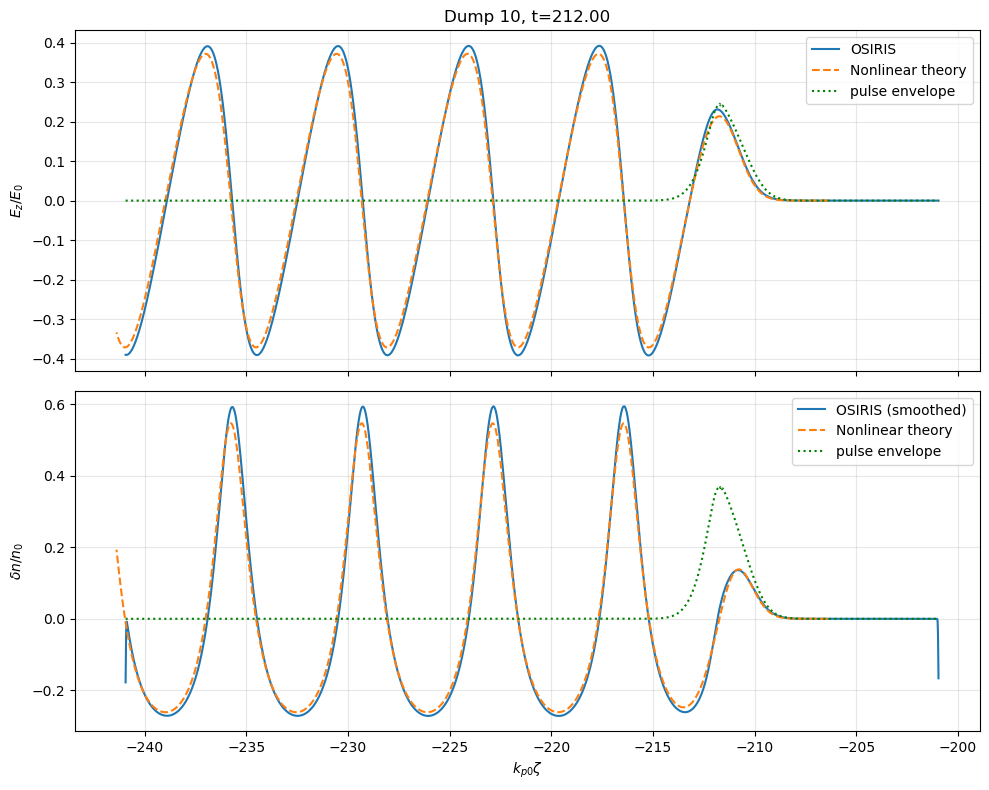

In [461]:
# Which dump do you want to look at?
dump = 10

# Define/calculate all of the relevant parameters we know based on the input deck to build the analytic solution
k_p = 1.0
k_carrier = 10.0
zeta_range = [5.0, -30.0]
v_g = k_carrier / np.sqrt(k_carrier**2 + 1.0)

# Get all of the relevant OSIRIS data for this dump
zeta, Ez, n_e, t, zeta_pho, n_pho = extract_data(dump, v_g=v_g)

# Smooth the electron density data because I was having issues with noise
n_e_smoothed = smooth_1d(n_e)
n_pho_smoothed = smooth_1d(n_pho)

a0_fit, L_rms_fit, z0_fit = fit_pulse_envelope(dump, v_g=v_g)
print(f"a0_fit={a0_fit}, L_rms_fit={L_rms_fit}, z0_fit={z0_fit}")

# Calculate the analytic nonlinear solution
zeta_an, Ez_an, dn_an, phi_an = solve_nonlinear_wake(a0=a0_fit, L_rms=L_rms_fit, k_p=k_p, 
                                               k_carrier=k_carrier, zeta_range=zeta_range, n_points=50000)

# Figure out where the wake starts (where it's above some threshold). We'll say that this is where the 
# beam/pulse/whatever "ends" so we can give that to our analytic solution. The threshold is a bit touchy.
active = np.abs(Ez) > 1e-8
zeta_pulse_end = zeta[active].max()

# Shift the values based on
active_an = np.abs(Ez_an) > 1e-8
zeta_an_pulse_end = zeta_an[active_an].max()
offset = zeta_pulse_end - zeta_an_pulse_end
zeta_an_shifted = zeta_an + offset

pulse_outline = smooth_1d(n_pho / n_pho.max() * np.max(np.abs(Ez)), passes=20)
pulse_outline_dn = smooth_1d(n_pho / n_pho.max() * np.max(np.abs(n_e_smoothed - 1.0)), passes=20)

# Create a figure like the linear case
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,8))

# On the top plot, put the axial electric field calculations
ax1.plot(zeta, Ez, label='OSIRIS')
ax1.plot(zeta_an_shifted, Ez_an, '--', label=r'Nonlinear theory')
ax1.plot(zeta_pho, pulse_outline, color='green', linestyle=':', label='pulse envelope')
ax1.set_ylabel(r'$E_z/E_0$'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title(f'Dump {dump}, t={t:.2f}')

ax2.plot(zeta, n_e_smoothed - 1.0, label='OSIRIS (smoothed)')
ax2.plot(zeta_an_shifted, dn_an, '--', label='Nonlinear theory')
ax2.plot(zeta_pho, pulse_outline_dn, color='green', linestyle=':', label='pulse envelope')
ax2.set_ylabel(r'$\delta n/n_0$'); ax2.set_xlabel(r'$k_{p0}\zeta$')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()

In [444]:
def plot_nonlinear_wake_with_photons(dump, v_g, k_laser, k_p=1.0, k_carrier=20.0,
                                       zeta_range=[5.0, -30.0], passes=30, figsize=(10, 12)):

    # --- 1. Wake data (Ez, n_e) in the co-moving frame ---
    zeta, Ez, n_e, t = extract_data(dump, v_g=v_g)
    n_e_smoothed = smooth_1d(n_e, passes=passes)

    # --- 2. Fit today's pulse parameters directly from the photon diagnostic ---
    a0_fit, L_rms_fit, z0_fit = fit_pulse_envelope(dump, v_g=v_g)

    # --- 3. Solve the nonlinear wake using today's fitted parameters ---
    zeta_an, Ez_an, dn_an, phi_an = solve_nonlinear_wake(
        a0=a0_fit, L_rms=L_rms_fit, k_p=k_p, k_carrier=k_carrier, zeta_range=zeta_range)

    # --- 4. Align theory to the simulation using the fitted pulse center ---
    order = np.argsort(zeta)
    zeta_sorted, Ez_sorted = zeta[order], Ez[order]
    active = np.abs(Ez_sorted) > 1e-5
    zeta_pulse_end = zeta_sorted[active].max()

    order_an = np.argsort(zeta_an)
    zeta_an_sorted, Ez_an_sorted = zeta_an[order_an], Ez_an[order_an]
    active_an = np.abs(Ez_an_sorted) > 1e-5
    zeta_an_pulse_end = zeta_an_sorted[active_an].max()

    offset = zeta_pulse_end - zeta_an_pulse_end
    zeta_an_shifted = zeta_an + offset

    # --- 5. Photon phase space, in the SAME co-moving frame as Ez/n_e ---
    dt_run = osiris_get_run_info("dt")
    ndumps_run = osiris_get_run_info("ndump")
    t_run = dump * dt_run * ndumps_run

    z_ph, p1_ph, p2_ph, p3_ph, ene_ph, wgt_ph = osiris_particles(dump, particles='photons')
    zeta_ph = z_ph - v_g * t_run   # convert to the same zeta convention as extract_data

    # --- Build the figure ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=figsize)

    ax1.plot(zeta, Ez, label='OSIRIS')
    ax1.plot(zeta_an_shifted, Ez_an, '--', label='Nonlinear theory')
    ax1.set_ylabel(r'$E_z/E_0$'); ax1.legend(); ax1.grid(alpha=0.3)
    ax1.set_title(f'Dump {dump}, t={t:.2f}')

    ax2.plot(zeta, n_e_smoothed - 1.0, label='OSIRIS (smoothed)')
    ax2.plot(zeta_an_shifted, dn_an, '--', label='Nonlinear theory')
    ax2.set_ylabel(r'$\delta n/n_0$'); ax2.legend(); ax2.grid(alpha=0.3)

    h, xedges, yedges = np.histogram2d(
        zeta_ph, p1_ph / k_laser, bins=[300, 200],
        range=[[zeta.min(), zeta.max()], [0.8, 1.2]],
        weights=wgt_ph
    )
    norm = PowerNorm(gamma=0.4, vmin=0, vmax=h.max())
    ax3.pcolormesh(xedges, yedges, h.T, cmap='Blues', shading='auto', norm=norm)
    ax3.set_ylabel(r'$k/\omega_0$')
    ax3.set_xlabel(r'$k_{p0}\zeta$')
    ax3.set_ylim(0.8, 1.2)
    ax3.grid(alpha=0.3)

    fig.tight_layout()
    return fig, (ax1, ax2, ax3)

# 07: Reitsma Paper Match

In [87]:
def plot_reitsma_snapshot(dump, k_laser, figsize=(6, 10)):
    fig, (ax_env, ax_spec, ax_phase) = plt.subplots(3, 1, figsize=figsize)

    # --- Envelope AA*(zeta) ---
    xi = osirisLoadGrid(dump, species='photons')
    n_pho = osirisLoadDensity(dump, species='photons')
    n_smooth = smooth_1d(n_pho, passes=20)
    ax_env.plot(xi, n_smooth, color='blue')
    ax_env.set_ylabel(r'$AA^*$')
    ax_env.set_ylim(0.0, 2.0)
    ax_env.grid(alpha=0.3)

    # --- Spectrum |A_hat|^2 ---
    z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles='photons')
    k_bins = np.linspace(0.9*k_laser, 1.1*k_laser, 200)
    spec, edges = np.histogram(p1, bins=k_bins, weights=wgt)
    k_centers = 0.5*(edges[1:]+edges[:-1])
    spec_raw_smooth = smooth_1d(spec, passes=10)
    spec_smooth = spec_raw_smooth / spec_raw_smooth.max()
    ax_spec.plot(k_centers/k_laser, spec_smooth, color='blue')
    ax_spec.set_ylabel('Spectrum (arb.)')
    ax_spec.set_xlabel(r'$k/\omega_0$')
    ax_spec.set_xlim(0.8, 1.2)
    ax_spec.grid(alpha=0.3)

    # --- Photon phase space ---
    ax_phase.scatter(z, p1, s=2*wgt/wgt.max(), alpha=0.15, color='blue', rasterized=True)
    ax_phase.set_ylabel(r'$k/\omega_0$')
    ax_phase.set_xlabel(r'$\omega_p\zeta$')
    ax_phase.set_ylim(19, 21)
    ax_phase.grid(alpha=0.3)

    fig.tight_layout()
    return fig, (ax_env, ax_spec, ax_phase)

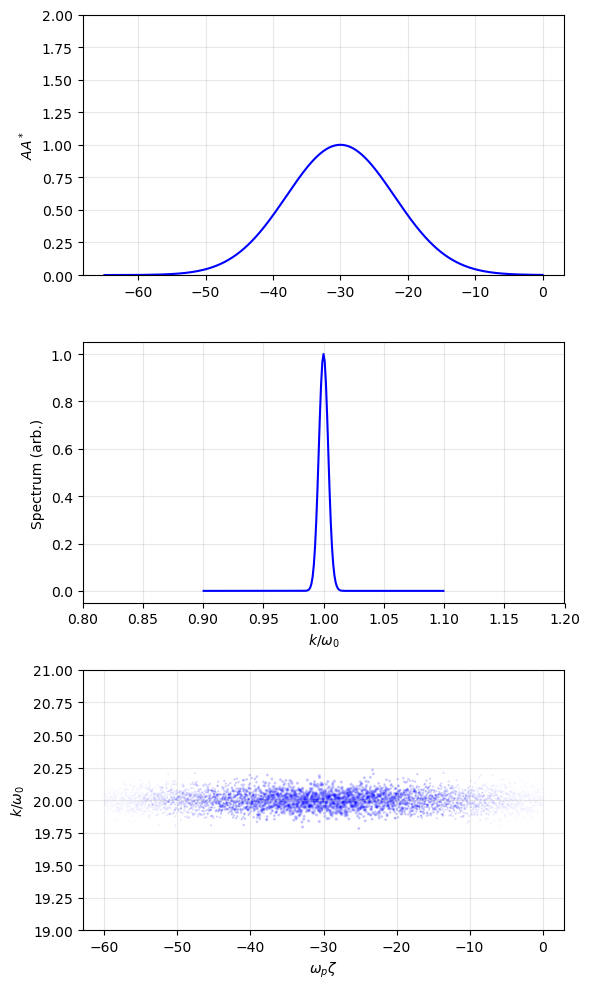

In [88]:
plot_reitsma_snapshot(0, k_laser=20.0);

# 08: AWAKE-like Simulation Diagnostics

In [28]:
def measure_em_widths(dump=0, z_step=1, xi_min=None):
    xi = osirisLoadGrid(dump)[::z_step]
    dxi = osirisGridSpacing(dump) * z_step
    if xi_min is None:
        xi_min = xi[0]
    xi_inds = (xi >= xi_min)
    xi = xi[xi_inds]

    E_x = osirisLoadEField(dump, component=2)[::z_step][xi_inds]
    power = np.abs(E_x)**2

    # position-space width (weighted by intensity)
    xi_centroid = np.sum(xi * power) / np.sum(power)
    sigma_xi = np.sqrt(np.sum(xi**2 * power) / np.sum(power) - xi_centroid**2)

    E_k = fft(E_x)
    k = 2 * np.pi * np.fft.fftfreq(len(xi), d=dxi)
    pos_mask = k > 0
    k_pos = k[pos_mask]
    powspectrum = np.abs(E_k[pos_mask])**2
    k_centroid = np.sum(k_pos * powspectrum) / np.sum(powspectrum)
    sigma_k = np.sqrt(np.sum((k_pos - k_centroid)**2 * powspectrum) / np.sum(powspectrum))

    return xi_centroid, sigma_xi, k_centroid, sigma_k

def measure_pkt_widths(dump=0):
    z, p1, p2, p3, ene, wgt = osiris_particles(dump, particles='photons')

    # position: weighted by macroparticle charge (density proxy)
    z_centroid = np.sum(wgt * z) / np.sum(wgt)
    sigma_z = np.sqrt(np.sum(wgt * (z - z_centroid)**2) / np.sum(wgt))

    # momentum: each particle independently sampled from uth, unweighted
    p1_mean = np.mean(p1)
    sigma_p1 = np.std(p1)

    return z_centroid, sigma_z, p1_mean, sigma_p1


# --- Run the comparison at the first frame (t~0) ---
xi_c, sigma_xi, k_c, sigma_k = measure_em_widths(dump=0)
z_c, sigma_z, p1_mean, sigma_p1 = measure_pkt_widths(dump=0)

print("=== Position-space width (EM sigma_xi vs PKT sigma_z) ===")
print(f"EM  measured sigma_xi:  {sigma_xi:.4f}   (centroid: {xi_c:.4f})")
print(f"PKT measured sigma_z:   {sigma_z:.4f}   (centroid: {z_c:.4f})")
print(f"Ratio (PKT/EM): {sigma_z/sigma_xi:.4f}")
print()
print("=== Momentum-space width (EM sigma_k vs PKT sigma_p1) ===")
print(f"EM  measured sigma_k:   {sigma_k:.4f}   (centroid: {k_c:.4f})")
print(f"PKT measured sigma_p1:  {sigma_p1:.4f}   (centroid/mean: {p1_mean:.4f})")
print(f"Ratio (PKT/EM): {sigma_p1/sigma_k:.4f}")

=== Position-space width (EM sigma_xi vs PKT sigma_z) ===
EM  measured sigma_xi:  0.3493   (centroid: -5.2998)
PKT measured sigma_z:   0.3536   (centroid: -5.3000)
Ratio (PKT/EM): 1.0122

=== Momentum-space width (EM sigma_k vs PKT sigma_p1) ===
EM  measured sigma_k:   1.4212   (centroid: 4.9938)
PKT measured sigma_p1:  1.4211   (centroid/mean: 4.9928)
Ratio (PKT/EM): 0.9999


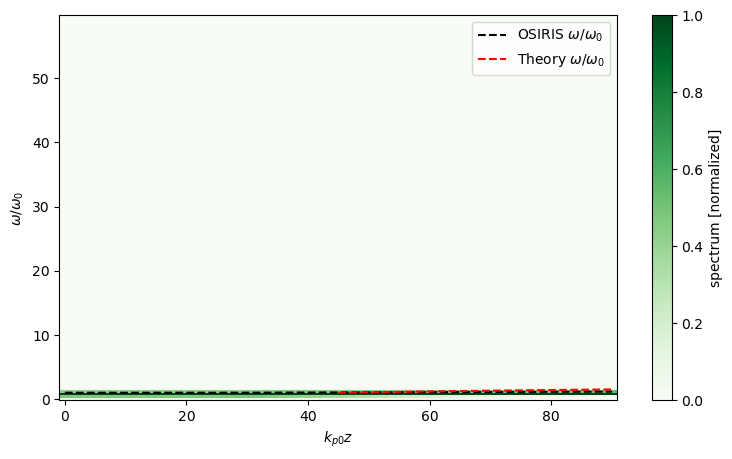

In [62]:
import numpy as np
import h5py
import glob
import re
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import dephasingless_pwpa_plasma_profile as depa


def model_func(x, *params):
    return params[0] + params[1] / (params[2] + x) ** params[3]


def dump_number(fn):
    m = re.search(r'(\d+)\.h5$', fn)
    return int(m.group(1)) if m else -1


def build_and_plot(
    driver_head_x1=20.0, nd0_np0=0.6, kp0Ld0=1.0, nc0_np0=25.93,
    ramp_width=1.0, v_g_ref=1.0,
    t_offset=0.0, z_start=0.0, xi_bins=None, omega_bins=None,
    kp0z_final=25000.0, core_n_sigma=5.0,
):
    if xi_bins is None:
        xi_bins = np.linspace(0, 25, 150)
    if omega_bins is None:
        omega_bins = np.linspace(0, 60, 150)
    omega0 = np.sqrt(nc0_np0)
    ramp_end = driver_head_x1 + ramp_width

    # --- fit density taper (used for the particle omega calculation) ---
    kp0z_fit, n_n0_fit, k_kp0_sq_fit = depa.get_pwpa_profile(
        nc0_np0, nd0_np0, kp0Ld0, kp0z_final=kp0z_final, n_steps=1601
    )
    taper_params, _ = curve_fit(
        model_func, kp0z_fit, n_n0_fit,
        p0=[0.25, 1.1, 20.0, 0.15]
    )

    def density_profile(x1):
        x1 = np.asarray(x1, dtype=float)
        s = x1 - ramp_end
        taper = model_func(np.clip(s, 0, None), *taper_params)
        return np.where(
            x1 <= driver_head_x1, 0.0,
            np.where(x1 <= ramp_end, (x1 - driver_head_x1) / ramp_width, taper)
        )

    # --- sort files numerically by dump number, not lexicographically ---
    photon_files = sorted(glob.glob("MS/RAW/photons/RAW-photons-*.h5"), key=dump_number)
    if not photon_files:
        raise FileNotFoundError("No RAW photon HDF5 files found in MS/RAW/photons/")

    envelope_img, spectrum_img, times, centroid_xi, centroid_omega = [], [], [], [], []
    for fn in photon_files:
        with h5py.File(fn, "r") as f:
            ds = f["x1"]
            if ds.shape == () or ds.shape[0] == 0:
                continue
            x1 = ds[:]
            p1 = f["p1"][:]
            q = f["q"][:]
            t = float(f.attrs["TIME"][0])
        w = np.abs(q)

        # single shared reference frame for all particles at this dump
        xi = x1 - v_g_ref * (t - t_offset)

        # --- gate to the pulse core before computing omega/centroid, so
        #     stray/separated macroparticles (e.g. low-p1 tail members that
        #     have drifted at a different group velocity) don't get counted
        #     with full weight in the spectrum or centroid ---
        xi_c = np.average(xi, weights=w)
        xi_spread = np.sqrt(np.average((xi - xi_c) ** 2, weights=w))
        core_mask = np.abs(xi - xi_c) < core_n_sigma * xi_spread

        x1_core = x1[core_mask]
        p1_core = p1[core_mask]
        w_core = w[core_mask]
        xi_core = xi[core_mask]

        n_local_core = density_profile(x1_core)
        omega_core = np.sqrt(p1_core ** 2 + n_local_core)
        omega_over_omega0_core = omega_core / omega0

        # envelope panel uses the full (ungated) population, so the real
        # spatial spread/tail is still visible there
        h_xi, _ = np.histogram(xi, bins=xi_bins, weights=w, density=True)
        envelope_img.append(h_xi)

        h_omega, _ = np.histogram(omega_over_omega0_core, bins=omega_bins,
                                   weights=w_core, density=True)
        spectrum_img.append(h_omega)

        times.append(t)
        centroid_xi.append(xi_c)
        centroid_omega.append(np.average(omega_over_omega0_core, weights=w_core))

    times = np.array(times)
    centroid_xi = np.array(centroid_xi)
    centroid_omega = np.array(centroid_omega)
    envelope_img = np.array(envelope_img).T
    spectrum_img = np.array(spectrum_img).T
    spectrum_img_norm = spectrum_img / (spectrum_img.max(axis=0, keepdims=True) + 1e-30)

    # --- theory overlay, same fitted profile as used for the particle data ---
    valid = times >= z_start
    kp0z_theory = times[valid] - z_start
    k_kp0_theory = np.interp(kp0z_theory, kp0z_fit, np.sqrt(k_kp0_sq_fit))
    theory_omega_over_omega0 = k_kp0_theory / omega0
    theory_t_axis = kp0z_theory + z_start

    plt.figure(figsize=(9, 5))
    im = plt.pcolormesh(times, omega_bins[:-1], spectrum_img_norm, cmap="Greens",
                          shading="auto", vmin=0, vmax=1)
    plt.plot(times, centroid_omega, color="black", linestyle="--", label=r"OSIRIS $\omega/\omega_0$")
    plt.plot(theory_t_axis, theory_omega_over_omega0, color="red", linestyle="--",
              label=r"Theory $\omega/\omega_0$")
    plt.ylabel(r"$\omega/\omega_0$")
    plt.xlabel(r"$k_{p0}z$")
    # plt.set_xlim(0, 5000)   # fixed: was set_xmin, not a real Axes method
    plt.legend()
    plt.colorbar(im, label="spectrum [normalized]")
    return 1


build_and_plot(driver_head_x1=1.0, ramp_width=30.0, nd0_np0=0.8, kp0Ld0=1.0,
                      nc0_np0=25.0, z_start=45.0, omega_bins=np.linspace(0, 60, 150));